In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Step 1: Create 1D data
x = np.random.randn(100)

# Step 2: Create correlated feature
y = 2 * x + np.random.randn(100) * 0.5

# Stack into dataset
X = np.column_stack((x, y))

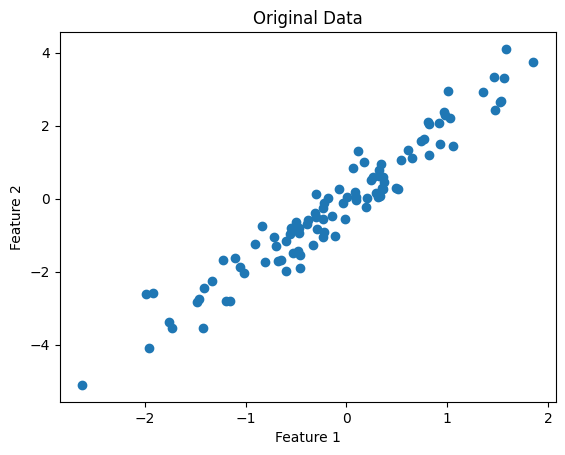

In [2]:
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [3]:
mean = np.mean(X, axis=0)
X_centered = X - mean

In [4]:
print(np.mean(X_centered, axis=0))

[4.30211422e-17 3.66373598e-17]


In [5]:
cov_matrix = np.cov(X_centered.T)

In [6]:
print(cov_matrix)

[[0.82476989 1.59046269]
 [1.59046269 3.29014231]]


In [7]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [8]:
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [0.04522181 4.0696904 ]
Eigenvectors:
 [[-0.89794091 -0.44011603]
 [ 0.44011603 -0.89794091]]


In [9]:
# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

In [10]:
# Take first principal component
PC1 = eigenvectors[:, 0]

# Project data
X_reduced = X_centered @ PC1

In [11]:
print(X_reduced.shape)

(100,)


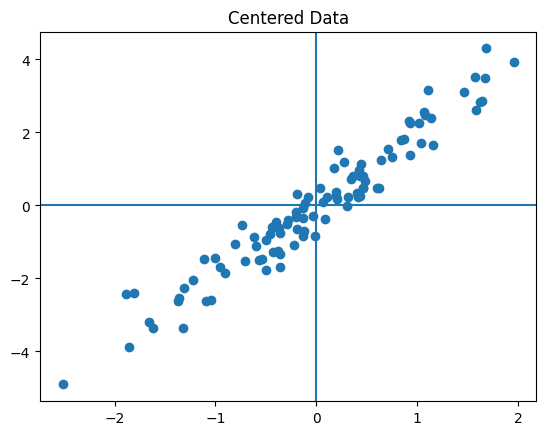

In [12]:
plt.scatter(X_centered[:, 0], X_centered[:, 1])
plt.title("Centered Data")
plt.axhline(0)
plt.axvline(0)
plt.show()

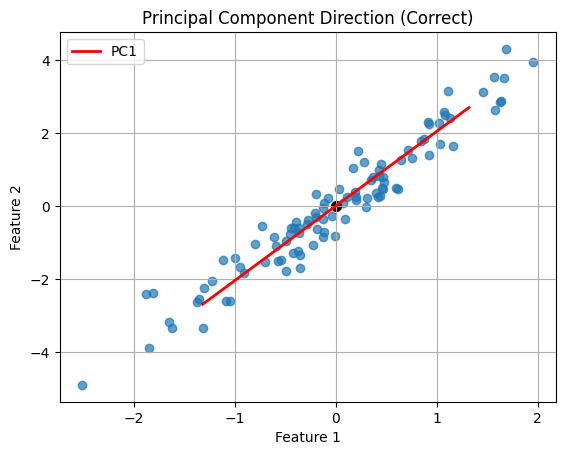

In [15]:
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.7)

# Draw proper PC1 line
line = np.linspace(-3, 3, 100)
plt.plot(line * PC1[0], line * PC1[1], color='red', linewidth=2, label='PC1')

# Mark origin
plt.scatter(0, 0, color='black', s=50)

plt.title("Principal Component Direction (Correct)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

plt.show()

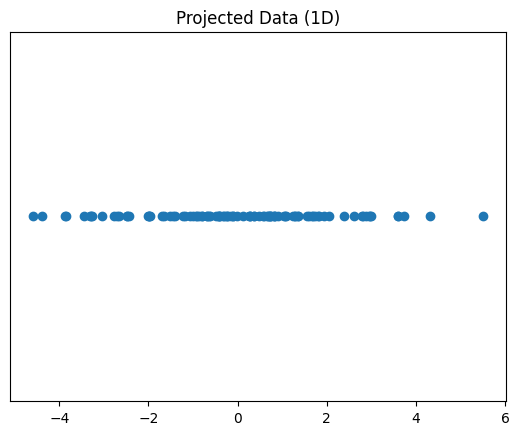

In [14]:
plt.scatter(X_reduced, np.zeros_like(X_reduced))
plt.title("Projected Data (1D)")
plt.yticks([])
plt.show()